NAIVE BAYES CLASSIFIER - PROFESSIONAL ANALYSIS
Save directory : /kaggle/working/nb_models/

BLOCK 1: LOADING DATASET
  Loaded in      : 2.0s
  Total samples  : 178,930
  Features       : 44
  Violation rate : 5.13%
  Normal         : 169,752
  Violated       : 9,178

BLOCK 2: TEMPORAL SPLIT
  Train : 135,986 | Violations: 6916 (5.09%)
  Val   : 33,997 | Violations: 1762 (5.18%)
  Test  : 8,947 | Violations: 500 (5.59%)

BLOCK 3: FEATURE SCALING
  Post-scale mean : -0.000000
  Post-scale std  : 1.000000

BLOCK 4: STRATIFIED UNDERSAMPLING
  Before : Normal=129,070 | Violated=6,916
  After  : Normal=20,748 | Violated=6,916

BLOCK 5: NAIVE BAYES MODEL
  Model : Gaussian Naive Bayes
  Hyperparameter to tune : var_smoothing

BLOCK 6: HYPERPARAMETER TUNING
  Best var_smoothing : 1.6297508346206469e-09
  Best CV AUPRC      : 0.7994
BLOCK 7: K-FOLD CROSS VALIDATION
Best var_smoothing used in CV : 1.6297508346206469e-09
  Fold 1/5 | AUPRC: 0.8172 | AUROC: 0.9084
  Fold 2/5 | AUPRC: 0.7824 | AURO

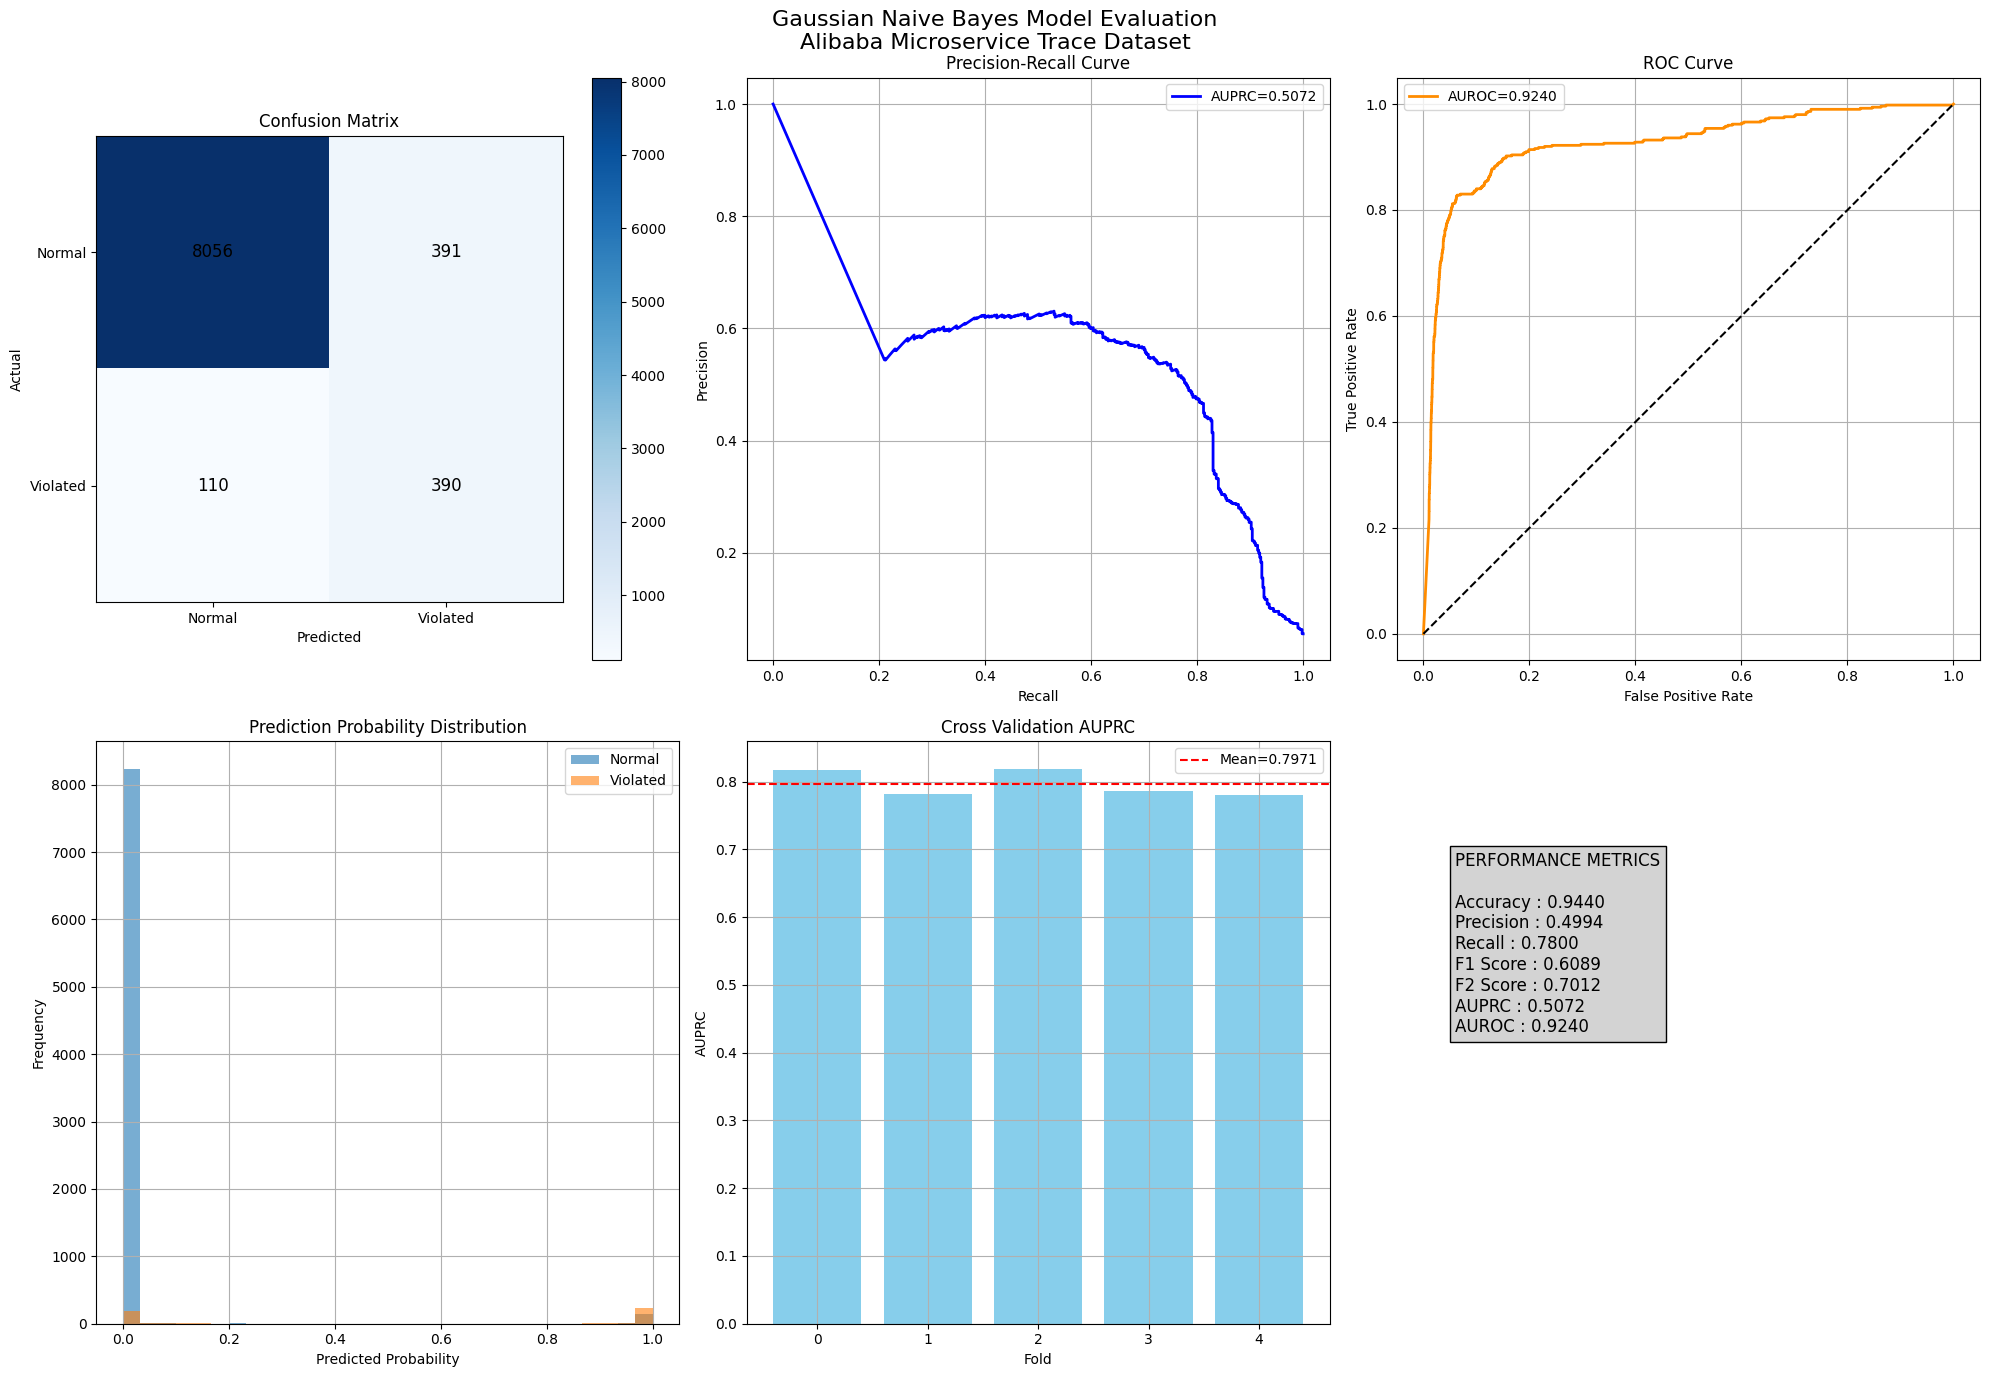

  nb_full_analysis.png : Saved


In [1]:
import os
import json
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve
)

import joblib

warnings.filterwarnings("ignore")

# =============================================================
# CONFIGURATION
# =============================================================
FILE_PATH = "/kaggle/input/datasets/harshavardhan0307/ml-project/Final_Topology_Dataset_FULL_0_to_5__2.csv"
SAVE_DIR = "/kaggle/working/nb_models/"
os.makedirs(SAVE_DIR, exist_ok=True)

print("=" * 60)
print("NAIVE BAYES CLASSIFIER - PROFESSIONAL ANALYSIS")
print("=" * 60)
print(f"Save directory : {SAVE_DIR}")
print("=" * 60)

# =============================================================
# BLOCK 1: LOAD DATASET
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 1: LOADING DATASET")
print("=" * 60)

t0 = time.time()

df = pd.read_csv(FILE_PATH)
df = df.sort_values("time_window").reset_index(drop=True)

NON_FEATURE_COLS = ['um','dm','time_window','violation_next_window']
FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURE_COLS]

X = df[FEATURE_COLS].fillna(-1).values
y = df["violation_next_window"].values

print(f"  Loaded in      : {time.time()-t0:.1f}s")
print(f"  Total samples  : {len(df):,}")
print(f"  Features       : {len(FEATURE_COLS)}")
print(f"  Violation rate : {y.mean()*100:.2f}%")
print(f"  Normal         : {(y==0).sum():,}")
print(f"  Violated       : {(y==1).sum():,}")

# =============================================================
# BLOCK 2: TEMPORAL SPLIT
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 2: TEMPORAL SPLIT")
print("=" * 60)

n=len(df)
test_start=int(n*0.95)
val_start=int(test_start*0.80)

X_train_raw=X[:val_start]
y_train_raw=y[:val_start]

X_val_raw=X[val_start:test_start]
y_val_raw=y[val_start:test_start]

X_test_raw=X[test_start:]
y_test_raw=y[test_start:]

print(f"  Train : {len(X_train_raw):,} | Violations: {y_train_raw.sum():.0f} ({y_train_raw.mean()*100:.2f}%)")
print(f"  Val   : {len(X_val_raw):,} | Violations: {y_val_raw.sum():.0f} ({y_val_raw.mean()*100:.2f}%)")
print(f"  Test  : {len(X_test_raw):,} | Violations: {y_test_raw.sum():.0f} ({y_test_raw.mean()*100:.2f}%)")

# =============================================================
# BLOCK 3: FEATURE SCALING
# =============================================================
print("\n"+"="*60)
print("BLOCK 3: FEATURE SCALING")
print("="*60)

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train_raw)
X_val_scaled=scaler.transform(X_val_raw)
X_test_scaled=scaler.transform(X_test_raw)

print(f"  Post-scale mean : {X_train_scaled.mean():.6f}")
print(f"  Post-scale std  : {X_train_scaled.std():.6f}")

# =============================================================
# BLOCK 4: STRATIFIED UNDERSAMPLING
# =============================================================
print("\n"+"="*60)
print("BLOCK 4: STRATIFIED UNDERSAMPLING")
print("="*60)

minority_idx=np.where(y_train_raw==1)[0]
majority_idx=np.where(y_train_raw==0)[0]

RATIO=3
n_majority=min(len(minority_idx)*RATIO,len(majority_idx))

sampled_majority=np.random.default_rng(42).choice(
    majority_idx,n_majority,replace=False
)

train_idx=np.concatenate([minority_idx,sampled_majority])
np.random.default_rng(42).shuffle(train_idx)

X_train_bal=X_train_scaled[train_idx]
y_train_bal=y_train_raw[train_idx]

print(f"  Before : Normal={len(majority_idx):,} | Violated={len(minority_idx):,}")
print(f"  After  : Normal={(y_train_bal==0).sum():,} | Violated={(y_train_bal==1).sum():,}")

# =============================================================
# BLOCK 5: NAIVE BAYES MODEL
# =============================================================
print("\n"+"="*60)
print("BLOCK 5: NAIVE BAYES MODEL")
print("="*60)

print("  Model : Gaussian Naive Bayes")
print("  Hyperparameter to tune : var_smoothing")


# =============================================================
# BLOCK 6: HYPERPARAMETER TUNING
# =============================================================
print("\n"+"="*60)
print("BLOCK 6: HYPERPARAMETER TUNING")
print("="*60)

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "var_smoothing": np.logspace(-12, -6, 100)
}

nb = GaussianNB()

search = RandomizedSearchCV(
    nb,
    param_grid,
    scoring="average_precision",
    cv=3,
    n_iter=20,
    random_state=42
)

search.fit(X_train_bal, y_train_bal)

best_model = search.best_estimator_

print(f"  Best var_smoothing : {search.best_params_['var_smoothing']}")
print(f"  Best CV AUPRC      : {search.best_score_:.4f}")
#BLOCK 7 :
print("BLOCK 7: K-FOLD CROSS VALIDATION")
print("="*60)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_auprcs = []
fold_aurocs = []

best_vs = search.best_params_["var_smoothing"]

print(f"Best var_smoothing used in CV : {best_vs}")

for i,(tr,vl) in enumerate(kf.split(X_train_bal,y_train_bal)):

    model = GaussianNB(var_smoothing=best_vs)

    model.fit(X_train_bal[tr], y_train_bal[tr])

    probs = model.predict_proba(X_train_bal[vl])[:,1]

    auprc = average_precision_score(y_train_bal[vl],probs)
    auroc = roc_auc_score(y_train_bal[vl],probs)

    fold_auprcs.append(auprc)
    fold_aurocs.append(auroc)

    print(f"  Fold {i+1}/5 | AUPRC: {auprc:.4f} | AUROC: {auroc:.4f}")

print(f"\n  Mean AUPRC : {np.mean(fold_auprcs):.4f} ± {np.std(fold_auprcs):.4f}")

# =============================================================
# BLOCK 8: THRESHOLD OPTIMIZATION
# =============================================================
print("\n"+"="*60)
print("BLOCK 8: THRESHOLD OPTIMIZATION")
print("="*60)

val_probs=best_model.predict_proba(X_val_scaled)[:,1]

precision_vals,recall_vals,thresholds=precision_recall_curve(
y_val_raw,val_probs
)

f2_scores=[fbeta_score(y_val_raw,(val_probs>=t).astype(int),beta=2) for t in thresholds]

best_thresh=thresholds[np.argmax(f2_scores)]

print(f"  Optimal threshold : {best_thresh:.4f}")

# =============================================================
# BLOCK 9: FINAL TEST SET EVALUATION
# =============================================================
print("\n"+"="*60)
print("BLOCK 9: FINAL TEST SET EVALUATION")
print("="*60)

test_probs=best_model.predict_proba(X_test_scaled)[:,1]

test_preds_opt=(test_probs>=best_thresh).astype(int)

test_auprc=average_precision_score(y_test_raw,test_probs)
test_auroc=roc_auc_score(y_test_raw,test_probs)

prec_opt=precision_score(y_test_raw,test_preds_opt)
rec_opt=recall_score(y_test_raw,test_preds_opt)
f1_opt=f1_score(y_test_raw,test_preds_opt)
f2_opt=fbeta_score(y_test_raw,test_preds_opt,beta=2)

acc_opt=(test_preds_opt==y_test_raw).mean()

print("\n"+"-"*60)
print("PERFORMANCE METRICS")
print("-"*60)

print(f"{'Metric':<20}{'Value':>10}")
print("-"*30)
print(f"{'Accuracy':<20}{acc_opt:>10.4f}")
print(f"{'Precision':<20}{prec_opt:>10.4f}")
print(f"{'Recall':<20}{rec_opt:>10.4f}")
print(f"{'F1 Score':<20}{f1_opt:>10.4f}")
print(f"{'F2 Score':<20}{f2_opt:>10.4f}")
print(f"{'AUPRC':<20}{test_auprc:>10.4f}")
print(f"{'AUROC':<20}{test_auroc:>10.4f}")

print("\nClassification Report")
print(classification_report(
y_test_raw,test_preds_opt,
target_names=["Normal","Violated"]
))


# =============================================================
# BLOCK 10: GENERATING PLOTS
# =============================================================
print("\n"+"="*60)
print("BLOCK 10: GENERATING PLOTS")
print("="*60)

fpr,tpr,_ = roc_curve(y_test_raw,test_probs)
prec_curve,rec_curve,_ = precision_recall_curve(y_test_raw,test_probs)

fig = plt.figure(figsize=(20,14))
gs = gridspec.GridSpec(2,3)

# -------------------------------------------------
# 1. Confusion Matrix
# -------------------------------------------------
ax1 = fig.add_subplot(gs[0,0])
cm = confusion_matrix(y_test_raw,test_preds_opt)

im = ax1.imshow(cm,cmap="Blues")

ax1.set_xticks([0,1])
ax1.set_yticks([0,1])
ax1.set_xticklabels(["Normal","Violated"])
ax1.set_yticklabels(["Normal","Violated"])

ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")
ax1.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax1.text(j,i,cm[i,j],ha="center",va="center",fontsize=12)

plt.colorbar(im,ax=ax1)

# -------------------------------------------------
# 2. Precision Recall Curve
# -------------------------------------------------
ax2 = fig.add_subplot(gs[0,1])

ax2.plot(rec_curve,prec_curve,color="blue",lw=2,
label=f"AUPRC={test_auprc:.4f}")

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.grid(True)
ax2.legend()

# -------------------------------------------------
# 3. ROC Curve
# -------------------------------------------------
ax3 = fig.add_subplot(gs[0,2])

ax3.plot(fpr,tpr,color="darkorange",lw=2,
label=f"AUROC={test_auroc:.4f}")

ax3.plot([0,1],[0,1],'k--')

ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC Curve")
ax3.grid(True)
ax3.legend()

# -------------------------------------------------
# 4. Probability Distribution
# -------------------------------------------------
ax4 = fig.add_subplot(gs[1,0])

ax4.hist(test_probs[y_test_raw==0],bins=30,
alpha=0.6,label="Normal")

ax4.hist(test_probs[y_test_raw==1],bins=30,
alpha=0.6,label="Violated")

ax4.set_title("Prediction Probability Distribution")
ax4.set_xlabel("Predicted Probability")
ax4.set_ylabel("Frequency")
ax4.legend()
ax4.grid(True)

# -------------------------------------------------
# 5. Cross Validation AUPRC
# -------------------------------------------------
ax5 = fig.add_subplot(gs[1,1])

x = np.arange(len(fold_auprcs))

ax5.bar(x,fold_auprcs,color="skyblue")

ax5.axhline(np.mean(fold_auprcs),color="red",
linestyle="--",label=f"Mean={np.mean(fold_auprcs):.4f}")

ax5.set_title("Cross Validation AUPRC")
ax5.set_xlabel("Fold")
ax5.set_ylabel("AUPRC")
ax5.legend()
ax5.grid(True)

# -------------------------------------------------
# 6. Performance Metrics Panel
# -------------------------------------------------
ax6 = fig.add_subplot(gs[1,2])
ax6.axis("off")

metrics_text = (
f"PERFORMANCE METRICS\n\n"
f"Accuracy : {acc_opt:.4f}\n"
f"Precision : {prec_opt:.4f}\n"
f"Recall : {rec_opt:.4f}\n"
f"F1 Score : {f1_opt:.4f}\n"
f"F2 Score : {f2_opt:.4f}\n"
f"AUPRC : {test_auprc:.4f}\n"
f"AUROC : {test_auroc:.4f}"
)

ax6.text(0.1,0.5,metrics_text,
fontsize=12,
bbox=dict(facecolor='lightgray',edgecolor='black'))

# -------------------------------------------------
plt.suptitle(
"Gaussian Naive Bayes Model Evaluation\nAlibaba Microservice Trace Dataset",
fontsize=16
)

plt.tight_layout()

plt.savefig(SAVE_DIR+"nb_full_analysis.png",dpi=150)

plt.show()

print("  nb_full_analysis.png : Saved")

